<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Pie Charts**


Estimated time needed: **30** minutes


- In this lab, you will focus on visualizing data.

- The provided dataset will be loaded into pandas for analysis.

- Various pie charts will be created to:
   - Analyze developer preferences.
  
   - Identify technology usage trends.
    
- The lab aims to provide insights into key variables using visual representations.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 124.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 169.2 MB/s eta 0:00:00


In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 131.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 155.5 MB/s eta 0:00:00


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-01-21 17:10:50--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  69.7MB/s    in 2.2s    

2026-01-21 17:10:52 (69.7 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Composition with Pie Charts


##### 1.1 Create a Pie Chart of the Top 5 Databases Respondents Want to Work With


In the survey data, the `DatabaseWantToWorkWith` column lists the databases that respondents wish to work with. Let’s visualize the top 5 most-desired databases in a pie chart.



In [5]:
# 1. Handle the 'DatabaseWantToWorkWith' column: split the strings and count occurrences.
# The entries need to be flattened into a single list before counting.
# Assuming the delimiter is a semicolon ';'. Adjust if necessary.
split_databases = df['DatabaseWantToWorkWith'].str.split(';')
all_databases = pd.Series(list(split_databases))

In [6]:
# Count the occurrences of each database
database_counts = all_databases.value_counts()

In [7]:
# 2. Select the top 5 most desired databases
top_5_databases = database_counts.head(5)

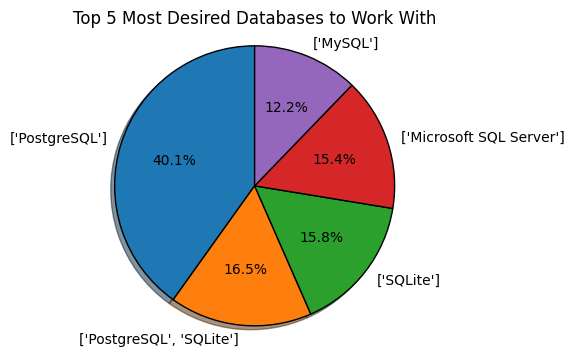

In [10]:
##Write your code here
# 3. Create the pie chart
plt.figure(figsize=(6, 4)) # Optional: adjust the figure size
# Use the pandas plotting function for simplicity, which wraps matplotlib's pie function
top_5_databases.plot.pie(
    autopct='%1.1f%%',   # Display percentages on the slices (e.g., 1.1f for one decimal place)
    startangle=90,       # Start angle for the first slice
    shadow=True,         # Add a shadow for a 3D effect
    labels=top_5_databases.index, # Use the database names as labels
    wedgeprops={'edgecolor': 'black'} # Optional: adds a black edge to slices
)
# Ensure the pie chart is a circle
plt.axis('equal')
# Add a title
plt.title('Top 5 Most Desired Databases to Work With')
# Display the chart
plt.show()

The `DevType` column lists the developer types for respondents. We’ll examine the distribution by showing the top 5 developer roles in a pie chart.



In [11]:
# 1. Parse the 'DevType' column and count occurrences
# The field is often semicolon-separated, so we split it and explode
dev_type_counts = df['DevType'].str.split(';').explode().value_counts()

In [12]:
# 2. Select the top 5 developer types
top5_dev_types = dev_type_counts.head(5)

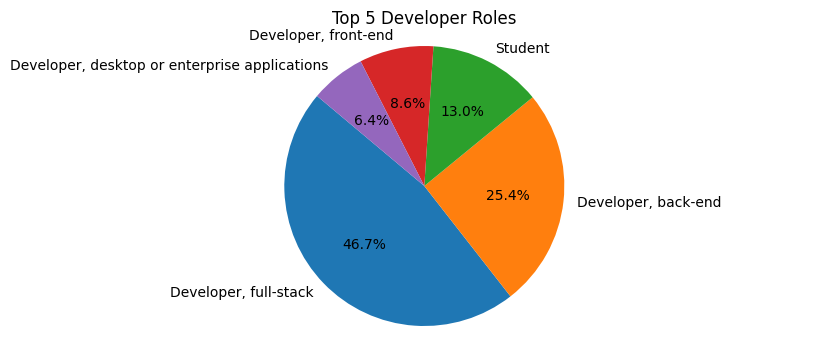

In [15]:
# 3. Create the pie chart
plt.figure(figsize=(10, 4))
plt.pie(top5_dev_types, labels=top5_dev_types.index, autopct='%1.1f%%', startangle=140)

# 4. Add title
plt.title('Top 5 Developer Roles')

# 5. Show plot
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

##### 1.3 Create a pie chart for the operating systems used by respondents for professional use


The `OpSysProfessional` use column shows the operating systems developers use professionally. Let’s visualize the distribution of the top operating systems in a pie chart.



In [45]:
opsys_cols = [col for col in df.columns if 'OpSys' in col]
print(opsys_cols)

['OpSysPersonal use', 'OpSysProfessional use']


In [52]:
OpSysPro_type_counts = df['OpSysProfessional use'].value_counts()

In [53]:
Top5_OpSysPro_types = OpSysPro_type_counts.head(5)

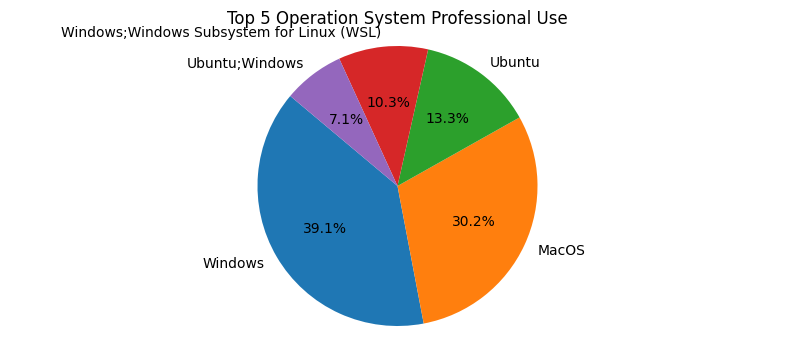

In [54]:
##Write your code here
# 3. Create the pie chart
plt.figure(figsize=(10, 4))
plt.pie(Top5_OpSysPro_types, labels=Top5_OpSysPro_types.index, autopct='%1.1f%%', startangle=140)

# 4. Add title
plt.title('Top 5 Operation System Professional Use')

# 5. Show plot
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Task 2: Additional Visualizations and Comparisons


##### 2.1 Pie Chart for Top 5 Programming Languages Respondents Have Worked With


The `LanguageHaveWorkedWith` column contains the programming languages that respondents have experience with. We’ll plot a pie chart to display the composition of the top 5 languages.



In [24]:
LW_type_counts = df['LanguageHaveWorkedWith'].str.split(';').explode().value_counts()

In [25]:
# 2. Select the top 5 developer types
top5_LW_types = LW_type_counts.head(5)

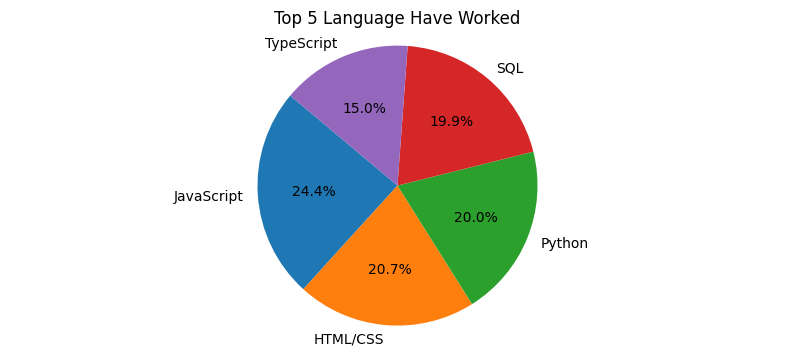

In [26]:
##Write your code here
# 3. Create the pie chart
plt.figure(figsize=(10, 4))
plt.pie(top5_LW_types, labels=top5_LW_types.index, autopct='%1.1f%%', startangle=140)
# 4. Add title
plt.title('Top 5 Language Have Worked')
# 5. Show plot
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

##### 2.2 Pie Chart for Top Collaboration Tools used in Professional Use


Using the `NEWCollabToolsHaveWorkedWith` column, we’ll identify and visualize the top collaboration tools respondents use in their professional work.



In [30]:
Collab_type_counts = df['NEWCollabToolsHaveWorkedWith'].str.split(';').explode().value_counts()

In [31]:
# 2. Select the top 5 developer types
top5_Collab_types = Collab_type_counts.head(5)

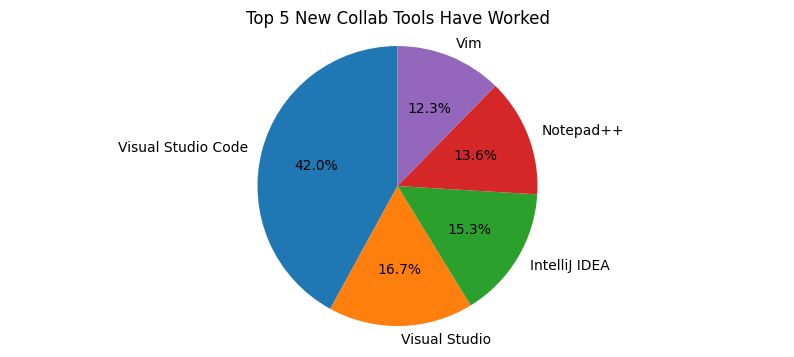

In [32]:
##Write your code here
# 3. Create the pie chart
plt.figure(figsize=(10, 4))
plt.pie(top5_Collab_types, labels=top5_Collab_types.index, autopct='%1.1f%%', startangle=90)
# 4. Add title
plt.title('Top 5 New Collab Tools Have Worked')
# 5. Show plot
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Task 3: Analyzing and Interpreting Composition


In this task, you will create additional pie charts to analyze specific aspects of the survey data. Use `pandas` and `matplotlib` to complete each task and interpret the findings.


##### 3.1 Pie Chart of `Respondents` Most Admired Programming Languages

The `LanguageAdmired` column lists the programming languages respondents admire most. Create a pie chart to visualize the top 5 admired languages.



In [34]:
LangAdmired_type_counts = df['LanguageAdmired'].str.split(';').explode().value_counts()

In [35]:
# 2. Select the top 5 developer types
top5_LangAdmired_types = LangAdmired_type_counts.head(5)

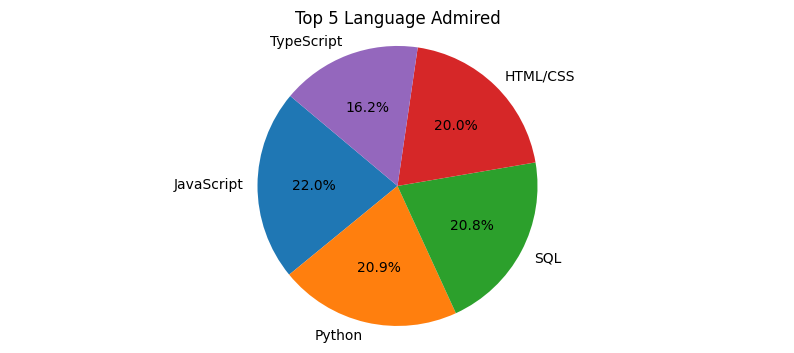

In [36]:
##Write your code here
# 3. Create the pie chart
plt.figure(figsize=(10, 4))
plt.pie(top5_LangAdmired_types, labels=top5_LangAdmired_types.index, autopct='%1.1f%%', startangle=140)
# 4. Add title
plt.title('Top 5 Language Admired')
# 5. Show plot
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

##### 3.2 Pie Chart of Tools Used for AI Development


Using the `AIToolCurrently` Using column, create a pie chart to visualize the top 5 tools developers are currently using for AI development.



In [39]:
ai_cols = [col for col in df.columns if 'AI' in col]
print(ai_cols)

['AISearchDevHaveWorkedWith', 'AISearchDevWantToWorkWith', 'AISearchDevAdmired', 'AISelect', 'AISent', 'AIBen', 'AIAcc', 'AIComplex', 'AIToolCurrently Using', 'AIToolInterested in Using', 'AIToolNot interested in Using', 'AINextMuch more integrated', 'AINextNo change', 'AINextMore integrated', 'AINextLess integrated', 'AINextMuch less integrated', 'AIThreat', 'AIEthics', 'AIChallenges']


In [41]:
#df['AIToolCurrently Using'].head()

In [42]:
AITool_type_counts = df['AIToolCurrently Using'].str.split(';').explode().value_counts()

In [43]:
# 2. Select the top 5 developer types
top5_AITool_types = AITool_type_counts.head(5)

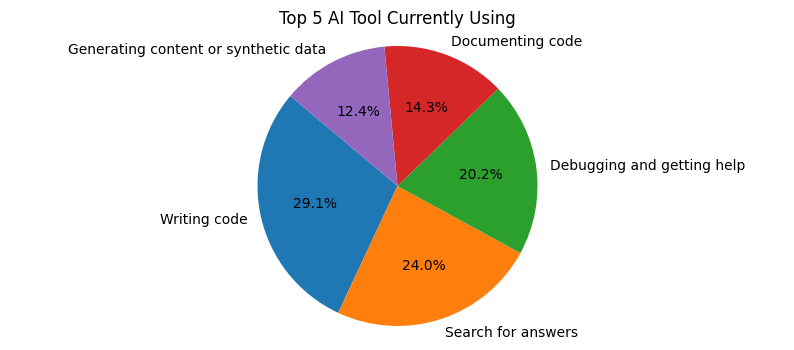

In [44]:
##Write your code here
# 3. Create the pie chart
plt.figure(figsize=(10, 4))
plt.pie(top5_AITool_types , labels=top5_AITool_types .index, autopct='%1.1f%%', startangle=140)
# 4. Add title
plt.title('Top 5 AI Tool Currently Using')
# 5. Show plot
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

##### 3.3 Pie Chart for Preferred Web Frameworks


The `WebframeWantToWorkWith` column includes web frameworks that respondents are interested in working with. Visualize the top 5 frameworks in a pie chart.



In [58]:
##Write your code here
#df['WebframeWantToWorkWith'].head()

In [59]:
WebFW_type_counts = df['WebframeWantToWorkWith'].str.split(';').explode().value_counts()

In [60]:
top5_WebFW_types = WebFW_type_counts.head(5)

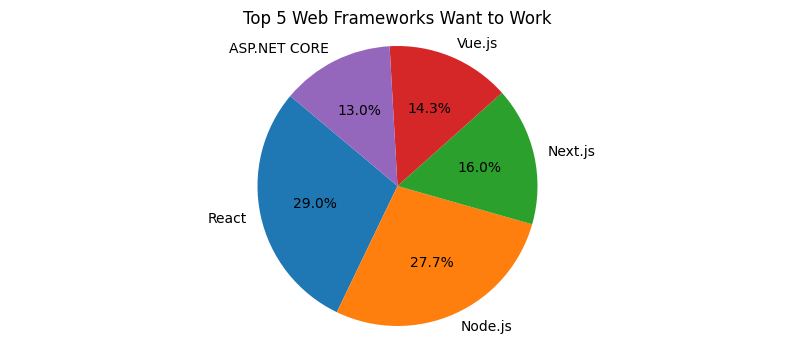

In [61]:
##Write your code here
# 3. Create the pie chart
plt.figure(figsize=(10, 4))
plt.pie(top5_WebFW_types , labels=top5_WebFW_types.index, autopct='%1.1f%%', startangle=140)
# 4. Add title
plt.title('Top 5 Web Frameworks Want to Work')
# 5. Show plot
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

##### 3.4 Pie Chart for Most Desired Embedded Technologies


Using the `EmbeddedWantToWorkWith` column, create a pie chart to show the top 5 most desired embedded technologies that respondents wish to work with.



In [62]:
#df['EmbeddedWantToWorkWith'].head()

In [63]:
Emb_type_counts = df['EmbeddedWantToWorkWith'].str.split(';').explode().value_counts()

In [64]:
top5_Emb_types = Emb_type_counts.head(5)

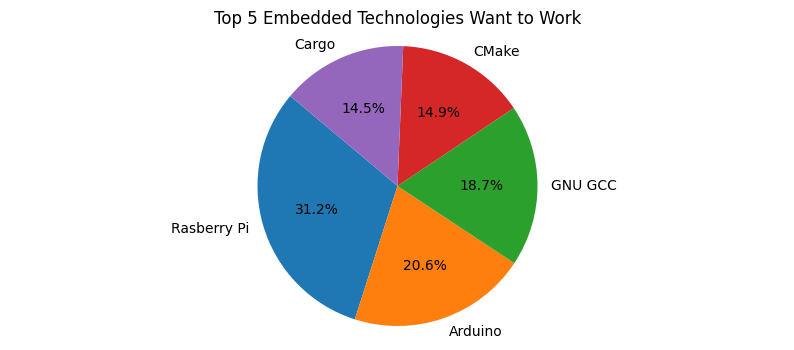

In [65]:
##Write your code here
# 3. Create the pie chart
plt.figure(figsize=(10, 4))
plt.pie(top5_Emb_types , labels=top5_Emb_types.index, autopct='%1.1f%%', startangle=140)
# 4. Add title
plt.title('Top 5 Embedded Technologies Want to Work')
# 5. Show plot
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Summary


After completing this lab, you will be able to:
- Create pie charts to visualize developer preferences across databases, programming languages, AI tools, and cloud platforms.
- Identify trends in technology usage, role distribution, and tool adoption through pie charts.
- Analyze and compare data composition across various categories to gain insights into developer preferences.




## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
